# 📊 Initial Exploratory Data Analysis (EDA)
**Objective:** Inspect the structure of the health behavior and obesity dataset, assess data quality, and identify the required preprocessing steps before applying clustering and data balancing models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Visual settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
df = pd.read_csv('../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv')

## 1. General Overview & Data Types

We evaluate the total number of records, features, data types, and check for missing values across the dataset.

In [2]:
# Dataset dimensions
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}\n")

# Summary of data types and null values
df.info()

Rows: 2111 | Columns: 17

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                

#### 💡 Structural Observations:
* **Missing Values:** Verify in the previous summary whether any columns contain fewer non-null values than total rows.
* **Data Types:** Identify numerical (`float64`, `int64`) vs. categorical (`object`) features to plan encoding strategies.
* **Duplicate Rows & Uniqueness:** Although exact duplicate rows may appear, they are not necessarily data entry errors. Because the dataset lacks a unique identifier (e.g., `user_id`), duplicate rows represent identical health profiles or response frequencies within the population survey. As a result, dropping them immediately could discard valid behavioral frequency data.

## 2. Statistical Summary

We analyze numerical distributions to detect potential outliers and review categorical features to understand label distributions.

In [3]:
# Descriptive statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


#### 💡 Observations on Numerical Features & Quality Issues

A detailed inspection of `df.describe().T` reveals key anomalies in features such as `NCP` (Number of Main Meals):

1. **Out-of-Range / Upper Bound Anomalies:**
   * `NCP` exhibits a maximum value of **`4.00`** (with over 200 rows exceeding `3.0`), which lies outside the standard expected 1–3 scale for discrete main meals.
2. **Synthetic Oversampling Artifacts (Continuous Values):**
   * Percentiles and intermediate values (e.g., 25th percentile = `2.658738`) confirm that `NCP` contains continuous floating-point numbers instead of discrete integers. 
   * This behavior is present across other discrete features (`Age`, `FCVC`, `CH2O`, `FAF`, `TUE`), confirming that synthetic data generation (such as SMOTE) was applied to the raw dataset.

> **Preprocessing Action Item:** In the data cleaning stage, bounded features must be clipped/capped to their valid domain ranges (e.g., clipping `NCP` to $[1, 3]$) and rounded or re-casted to integer types where applicable.

### 🔍 Categorical Feature Inspection
Review unique categories across qualitative variables (eating habits, physical activity, alcohol/tobacco consumption, transportation, etc.).

In [4]:
# Descriptive statistics for categorical variables
df.describe(include=['O']).T

,count,unique,top,freq
Gender,2111,2,Male,1068
family_history_with_overweight,2111,2,yes,1726
FAVC,2111,2,yes,1866
CAEC,2111,4,Sometimes,1765
SMOKE,2111,2,no,2067
SCC,2111,2,no,2015
CALC,2111,4,Sometimes,1401
MTRANS,2111,5,Public_Transportation,1580
NObeyesdad,2111,7,Obesity_Type_I,351


## 3. Obesity Level Distribution (`NObeyesdad`)

We analyze class balance across the target obesity classification variable.

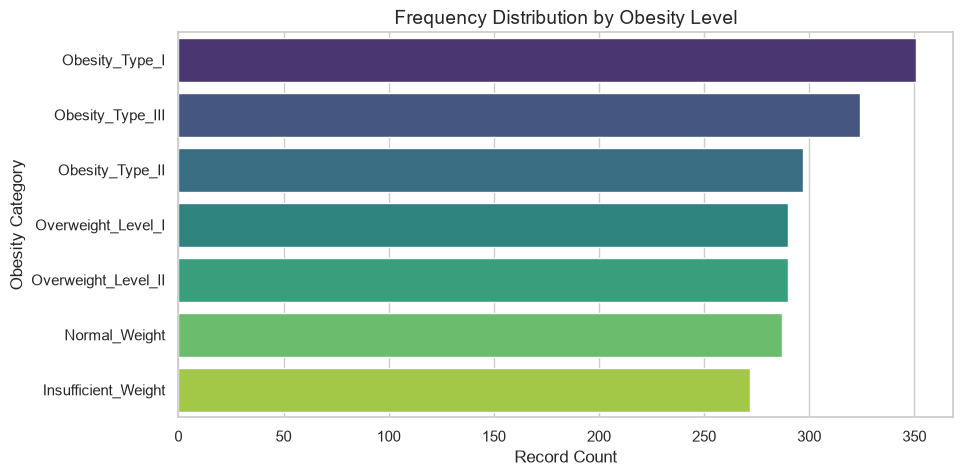

In [6]:
# Class frequency visualization
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='viridis')
plt.title('Frequency Distribution by Obesity Level', fontsize=14)
plt.xlabel('Record Count')
plt.ylabel('Obesity Category')
plt.savefig('../visuals/frequency_distribution_by_obesity_level.png', dpi=300, bbox_inches='tight')
plt.show()

## 🛠️ Required Data Preprocessing Roadmap

Based on the preliminary inspection, the following steps are defined for the next pipeline stage:

1. **Categorical Encoding:** Apply *One-Hot Encoding* or *Ordinal Encoding* according to feature types (e.g., binary yes/no responses vs. ordinal scales).
2. **Feature Scaling:** Apply `StandardScaler` to numerical columns (Age, Weight, Height, activity frequencies) to normalize ranges prior to K-Means clustering.
3. **Imbalance / Resampling:** Evaluate the necessity of synthetic oversampling (**SMOTE**) to ensure balanced class representation across clusters.